GitHub Machine Learning Repositories Analysis

## Task 1: Data Collection and Preparation

In this task, repository data is collected from the GitHub API, explored and prepared using Python and Pandas. The dataset is cleaned, structured, and saved as a CSV file for the next stages of the project.

In [24]:
import requests
import pandas as pd

 1. Fetch Data from GitHub API

The GitHub API is used to collect information about Machine Learning repositories. The repositories are sorted by the number of stars in descending order.

In [25]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)
response.raise_for_status()

data = response.json()

print("Data collected successfully.")
print("Number of repositories:", len(data["items"]))

Data collected successfully.
Number of repositories: 100


2. Create and Explore the DataFrame

The JSON response contains repository information inside the items field. This data is converted into a Pandas DataFrame for exploration and preparation.

In [26]:
df = pd.DataFrame(data["items"])

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (100, 82)


,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76070,3070,197067,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34290,2385,164264,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21979,13,89536,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15266,52,82547,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15614,26,74075,master,1.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [28]:
df.columns.tolist()

['id',
 'node_id',
 'name',
 'full_name',
 'private',
 'owner',
 'html_url',
 'description',
 'fork',
 'url',
 'forks_url',
 'keys_url',
 'collaborators_url',
 'teams_url',
 'hooks_url',
 'issue_events_url',
 'events_url',
 'assignees_url',
 'branches_url',
 'tags_url',
 'blobs_url',
 'git_tags_url',
 'git_refs_url',
 'trees_url',
 'statuses_url',
 'languages_url',
 'stargazers_url',
 'contributors_url',
 'subscribers_url',
 'subscription_url',
 'commits_url',
 'git_commits_url',
 'comments_url',
 'issue_comment_url',
 'contents_url',
 'compare_url',
 'merges_url',
 'archive_url',
 'downloads_url',
 'issues_url',
 'pulls_url',
 'milestones_url',
 'notifications_url',
 'labels_url',
 'releases_url',
 'deployments_url',
 'created_at',
 'updated_at',
 'pushed_at',
 'git_url',
 'ssh_url',
 'clone_url',
 'svn_url',
 'homepage',
 'size',
 'stargazers_count',
 'watchers_count',
 'language',
 'has_issues',
 'has_projects',
 'has_downloads',
 'has_wiki',
 'has_pages',
 'has_discussions',
 'fork

3. Select Relevant Fields

The dataset contains many fields returned by the GitHub API. Only the fields needed for the analysis are selected.

In [29]:
selected_columns = [
    "name",
    "full_name",
    "html_url",
    "description",
    "language",
    "stargazers_count",
    "forks_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "owner",
    "license"
]

df = df[selected_columns]

df.head()

,name,full_name,html_url,description,language,stargazers_count,forks_count,open_issues_count,created_at,updated_at,owner,license
0,tensorflow,tensorflow/tensorflow,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,197067,76070,3070,2015-11-07T01:19:20Z,2026-08-19T18:23:35Z,"{'login': 'tensorflow', 'id': 15658638, 'node_...","{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,huggingface/transformers,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,164264,34290,2385,2018-10-29T13:56:00Z,2026-08-19T17:38:03Z,"{'login': 'huggingface', 'id': 25720743, 'node...","{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,microsoft/ML-For-Beginners,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",Jupyter Notebook,89536,21979,13,2021-03-03T01:34:05Z,2026-08-19T17:36:12Z,"{'login': 'microsoft', 'id': 6154722, 'node_id...","{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,fighting41love/funNLP,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,Python,82547,15266,52,2018-08-21T11:20:39Z,2026-08-19T15:32:46Z,"{'login': 'fighting41love', 'id': 11475294, 'n...",None
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,Python,74075,15614,26,2014-07-15T19:11:19Z,2026-08-19T17:50:14Z,"{'login': 'josephmisiti', 'id': 246302, 'node_...","{'key': 'other', 'name': 'Other', 'spdx_id': '..."


4. Extract Nested Data

Some repository information is stored inside nested objects. The owner's login name and license name are extracted into separate columns to make the dataset easier to analyze and store in a database.

In [30]:
df["owner_login"] = df["owner"].apply(
    lambda x: x.get("login") if isinstance(x, dict) else None
)

df["license_name"] = df["license"].apply(
    lambda x: x.get("name") if isinstance(x, dict) else None
)

df = df.drop(columns=["owner", "license"])

df.head()

,name,full_name,html_url,description,language,stargazers_count,forks_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,tensorflow/tensorflow,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,197067,76070,3070,2015-11-07T01:19:20Z,2026-08-19T18:23:35Z,tensorflow,Apache License 2.0
1,transformers,huggingface/transformers,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,164264,34290,2385,2018-10-29T13:56:00Z,2026-08-19T17:38:03Z,huggingface,Apache License 2.0
2,ML-For-Beginners,microsoft/ML-For-Beginners,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",Jupyter Notebook,89536,21979,13,2021-03-03T01:34:05Z,2026-08-19T17:36:12Z,microsoft,MIT License
3,funNLP,fighting41love/funNLP,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,Python,82547,15266,52,2018-08-21T11:20:39Z,2026-08-19T15:32:46Z,fighting41love,None
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,Python,74075,15614,26,2014-07-15T19:11:19Z,2026-08-19T17:50:14Z,josephmisiti,Other


5. Explore Missing and Duplicate Data

The dataset is checked for missing values and duplicate records before cleaning.

In [31]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
name                  0
full_name             0
html_url              0
description           0
language             23
stargazers_count      0
forks_count           0
open_issues_count     0
created_at            0
updated_at            0
owner_login           0
license_name         22
dtype: int64


In [32]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


6. Clean the Dataset

Missing values in text fields are replaced with suitable values, and duplicate records are removed

In [33]:
df["description"] = df["description"].fillna("No description")
df["language"] = df["language"].fillna("Unknown")
df["owner_login"] = df["owner_login"].fillna("Unknown")
df["license_name"] = df["license_name"].fillna("No license")

df = df.drop_duplicates()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (100, 12)


7. Prepare Data Types

Date columns are converted to datetime format, while numerical columns are converted to numeric values to prepare the dataset for database storage and analysis.

In [34]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

numeric_columns = [
    "stargazers_count",
    "forks_count",
    "open_issues_count"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   name               100 non-null    object             
 1   full_name          100 non-null    object             
 2   html_url           100 non-null    object             
 3   description        100 non-null    object             
 4   language           100 non-null    object             
 5   stargazers_count   100 non-null    int64              
 6   forks_count        100 non-null    int64              
 7   open_issues_count  100 non-null    int64              
 8   created_at         100 non-null    datetime64[ns, UTC]
 9   updated_at         100 non-null    datetime64[ns, UTC]
 10  owner_login        100 non-null    object             
 11  license_name       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(3), object(7)
memo

8. Final Dataset Check

The cleaned dataset is checked again to make sure that the required fields are available and the data is ready to be saved.

In [35]:
print("Final dataset shape:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

df.head()

Final dataset shape: (100, 12)

Missing values after cleaning:
name                 0
full_name            0
html_url             0
description          0
language             0
stargazers_count     0
forks_count          0
open_issues_count    0
created_at           0
updated_at           0
owner_login          0
license_name         0
dtype: int64

Duplicate rows after cleaning:
0


,name,full_name,html_url,description,language,stargazers_count,forks_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,tensorflow/tensorflow,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,197067,76070,3070,2015-11-07 01:19:20+00:00,2026-08-19 18:23:35+00:00,tensorflow,Apache License 2.0
1,transformers,huggingface/transformers,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,164264,34290,2385,2018-10-29 13:56:00+00:00,2026-08-19 17:38:03+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,microsoft/ML-For-Beginners,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",Jupyter Notebook,89536,21979,13,2021-03-03 01:34:05+00:00,2026-08-19 17:36:12+00:00,microsoft,MIT License
3,funNLP,fighting41love/funNLP,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,Python,82547,15266,52,2018-08-21 11:20:39+00:00,2026-08-19 15:32:46+00:00,fighting41love,No license
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,Python,74075,15614,26,2014-07-15 19:11:19+00:00,2026-08-19 17:50:14+00:00,josephmisiti,Other


9. Save the Prepared Dataset

The final prepared dataset is saved as github_projects.csv.

In [36]:
df.to_csv("github_projects.csv", index=False)

print("github_projects.csv saved successfully.")

github_projects.csv saved successfully.


10. Verify the Saved Dataset

The saved CSV file is loaded again to verify that the data was stored correctly and is ready for the next stage of the project.

In [37]:
df_check = pd.read_csv("github_projects.csv")

print("Reloaded dataset shape:", df_check.shape)

df_check.head()

Reloaded dataset shape: (100, 12)


,name,full_name,html_url,description,language,stargazers_count,forks_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,tensorflow/tensorflow,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,197067,76070,3070,2015-11-07 01:19:20+00:00,2026-08-19 18:23:35+00:00,tensorflow,Apache License 2.0
1,transformers,huggingface/transformers,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,164264,34290,2385,2018-10-29 13:56:00+00:00,2026-08-19 17:38:03+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,microsoft/ML-For-Beginners,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",Jupyter Notebook,89536,21979,13,2021-03-03 01:34:05+00:00,2026-08-19 17:36:12+00:00,microsoft,MIT License
3,funNLP,fighting41love/funNLP,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,Python,82547,15266,52,2018-08-21 11:20:39+00:00,2026-08-19 15:32:46+00:00,fighting41love,No license
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,Python,74075,15614,26,2014-07-15 19:11:19+00:00,2026-08-19 17:50:14+00:00,josephmisiti,Other


In [38]:
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               100 non-null    object
 1   full_name          100 non-null    object
 2   html_url           100 non-null    object
 3   description        100 non-null    object
 4   language           100 non-null    object
 5   stargazers_count   100 non-null    int64 
 6   forks_count        100 non-null    int64 
 7   open_issues_count  100 non-null    int64 
 8   created_at         100 non-null    object
 9   updated_at         100 non-null    object
 10  owner_login        100 non-null    object
 11  license_name       100 non-null    object
dtypes: int64(3), object(9)
memory usage: 9.5+ KB


Task 1 Completed

The GitHub repository data was collected through the GitHub API, converted into a Pandas DataFrame, explored, and prepared. Relevant fields were selected, nested owner and license information was extracted, missing and duplicate data was handled, data types were prepared, and the final dataset was saved and verified as github_projects.csv.

Task 2: Data Storage and Analysis

In this task, the prepared GitHub repository dataset is stored in a SQLite database and analyzed using SQL. The analysis includes filtering, searching, logical operators, sorting, aggregate functions, grouping, and data visualization using Matplotlib.

In [39]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

1. Create SQLite Database

The prepared CSV dataset from Task 1 is loaded and stored in a SQLite database. The data is imported into a table named Repositories.

In [40]:
df = pd.read_csv("github_projects.csv")

conn = sqlite3.connect("github_projects.db")

df.to_sql("Repositories", conn, if_exists="replace", index=False)

print("Data imported successfully into the Repositories table.")

Data imported successfully into the Repositories table.


2. Filtering Repositories by Stars

This query filters repositories that have more than 10,000 stars.
Cell 6 — Code

In [41]:
query = """
SELECT name, stargazers_count, language
FROM Repositories
WHERE stargazers_count > 10000
"""

over_10000 = pd.read_sql_query(query, conn)

over_10000

,name,stargazers_count,language
0,tensorflow,197067,C++
1,transformers,164264,Python
2,ML-For-Beginners,89536,Jupyter Notebook
3,funNLP,82547,Python
4,awesome-machine-learning,74075,Python
...,...,...,...
65,machine-learning-systems-design,10531,HTML
66,Machine-Learning,10371,Python
67,machine-learning-notes,10332,Jupyter Notebook
68,3D-Machine-Learning,10192,Unknown


3. Searching Repository Names

This query finds repositories whose names contain the word "Machine".

In [42]:
query = """
SELECT name, stargazers_count, language
FROM Repositories
WHERE name LIKE '%Machine%'
"""

machine_repositories = pd.read_sql_query(query, conn)

machine_repositories

,name,stargazers_count,language
0,awesome-machine-learning,74075,Python
1,500-AI-Machine-learning-Deep-learning-Computer...,36385,Unknown
2,machine-learning-for-software-engineers,28864,Unknown
3,homemade-machine-learning,24769,Jupyter Notebook
4,awesome-production-machine-learning,20851,Unknown
5,machine-learning-for-trading,20517,Jupyter Notebook
6,stanford-cs-229-machine-learning,20130,Unknown
7,Machine-Learning-Tutorials,18110,Unknown
8,machine-learning-zoomcamp,13947,Jupyter Notebook
9,machine-learning-interview,12784,Unknown


4. Logical Operator: AND

The AND operator is used to combine two conditions. The query finds repositories with more than 10,000 stars that use Python.

In [43]:
query = """
SELECT name, stargazers_count, language
FROM Repositories
WHERE stargazers_count > 10000
AND language = 'Python'
"""

and_result = pd.read_sql_query(query, conn)

and_result

,name,stargazers_count,language
0,transformers,164264,Python
1,funNLP,82547,Python
2,awesome-machine-learning,74075,Python
3,scikit-learn,66971,Python
4,gradio,43388,Python
5,ML-From-Scratch,32494,Python
6,linkedin-skill-assessments-quizzes,28805,Python
7,cs249r_book,27959,Python
8,onnx,21330,Python
9,rasa,21296,Python


5. Logical Operator: OR

The OR operator is used to find repositories that use either Python or JavaScript.

In [44]:
query = """
SELECT name, stargazers_count, language
FROM Repositories
WHERE language = 'Python'
OR language = 'JavaScript'
"""

or_result = pd.read_sql_query(query, conn)

or_result

,name,stargazers_count,language
0,transformers,164264,Python
1,funNLP,82547,Python
2,awesome-machine-learning,74075,Python
3,scikit-learn,66971,Python
4,gradio,43388,Python
5,netron,33368,JavaScript
6,ML-From-Scratch,32494,Python
7,linkedin-skill-assessments-quizzes,28805,Python
8,cs249r_book,27959,Python
9,onnx,21330,Python


6. Logical Operator: NOT

The NOT operator is used to exclude repositories that use Python.

In [45]:
query = """
SELECT name, stargazers_count, language
FROM Repositories
WHERE NOT language = 'Python'
"""

not_result = pd.read_sql_query(query, conn)

not_result

,name,stargazers_count,language
0,tensorflow,197067,C++
1,ML-For-Beginners,89536,Jupyter Notebook
2,500-AI-Machine-learning-Deep-learning-Computer...,36385,Unknown
3,C-Plus-Plus,34588,C++
4,netron,33368,JavaScript
...,...,...,...
65,Machine-learning-learning-notes,7762,Unknown
66,awesome-youtubers,7701,Markdown
67,Learn_Machine_Learning_in_3_Months,7606,Unknown
68,h2o-3,7493,Jupyter Notebook


7. Sorting and Limiting Results

The repositories are sorted by the number of stars in descending order. The top 10 repositories are then selected.

In [46]:
query = """
SELECT name, stargazers_count, language
FROM Repositories
ORDER BY stargazers_count DESC
LIMIT 10
"""

top10 = pd.read_sql_query(query, conn)

top10

,name,stargazers_count,language
0,tensorflow,197067,C++
1,transformers,164264,Python
2,ML-For-Beginners,89536,Jupyter Notebook
3,funNLP,82547,Python
4,awesome-machine-learning,74075,Python
5,scikit-learn,66971,Python
6,gradio,43388,Python
7,500-AI-Machine-learning-Deep-learning-Computer...,36385,Unknown
8,C-Plus-Plus,34588,C++
9,netron,33368,JavaScript


8. Total Number of Repositories

The COUNT function is used to calculate the total number of repositories in the dataset.

In [47]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories
"""

total_repositories = pd.read_sql_query(query, conn)

total_repositories

,total_repositories
0,100


9. Average Number of Stars

The AVG function is used to calculate the average number of stars across all repositories.

In [48]:
query = """
SELECT AVG(stargazers_count) AS average_stars
FROM Repositories
"""

average_stars = pd.read_sql_query(query, conn)

average_stars

,average_stars
0,20808.62


10. Repository Count by Programming Language

Repositories are grouped by programming language. Only programming languages with more than 5 repositories are displayed.

In [49]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC
"""

language_counts = pd.read_sql_query(query, conn)

language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


11. Visualization: Top 10 Most Popular Repositories

A bar chart is created to show the top 10 repositories with the highest number of stars.

/tmp/ipykernel_2403/1860125515.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


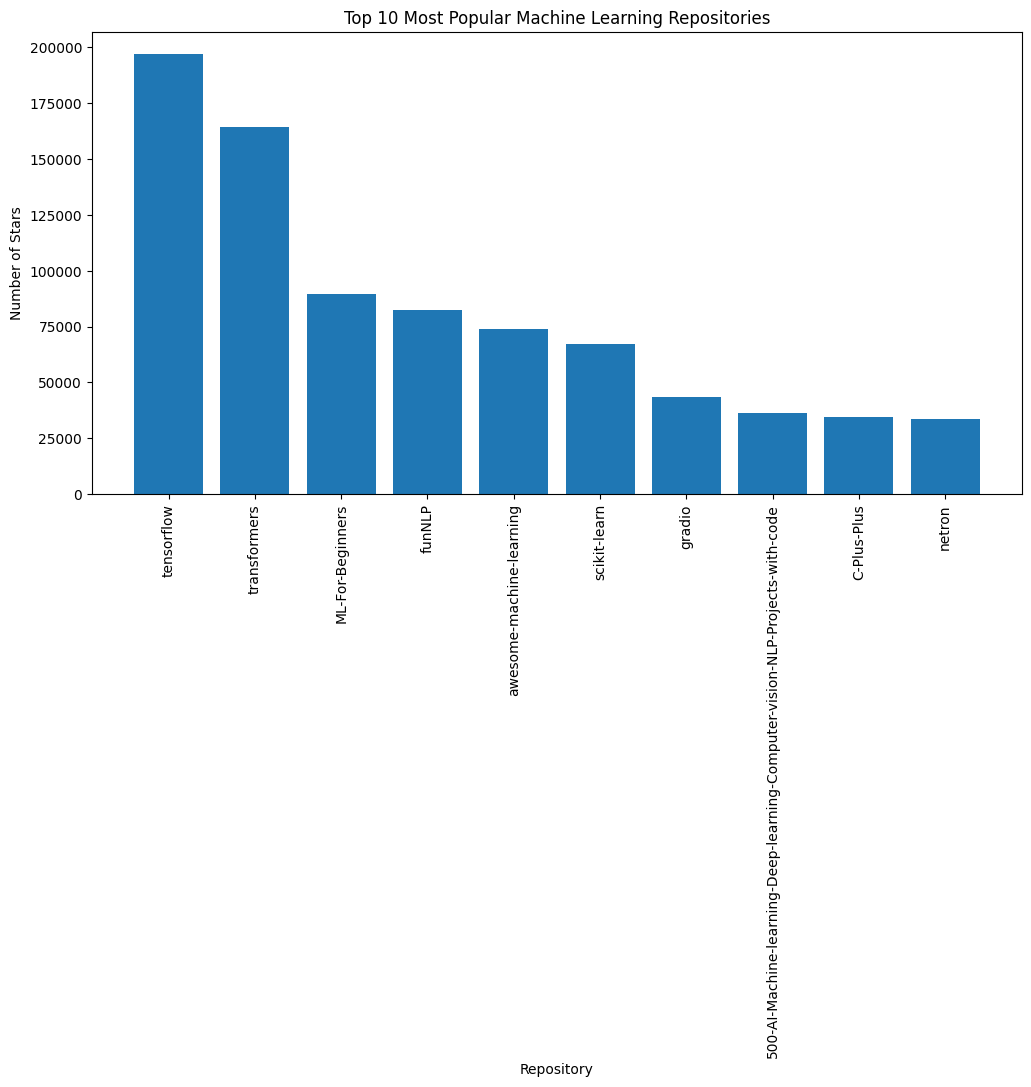

In [50]:
plt.figure(figsize=(12, 6))

plt.bar(top10["name"], top10["stargazers_count"])

plt.xlabel("Repository")
plt.ylabel("Number of Stars")
plt.title("Top 10 Most Popular Machine Learning Repositories")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

12. Repository Creation Trends

The repository creation dates are analyzed by year to identify changes in repository creation activity over time.

In [51]:
df["created_at"] = pd.to_datetime(df["created_at"])

df["creation_year"] = df["created_at"].dt.year

creation_trends = (
    df.groupby("creation_year")
      .size()
      .reset_index(name="repository_count")
)

creation_trends

,creation_year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


Task 3: Ethics Reflection

 1. Why is it important to verify data collected from public APIs?

It is important to verify data collected from public APIs because the data may contain missing, incorrect, outdated, or inconsistent information. Verifying the data helps ensure that the analysis is based on reliable information and that the results are accurate.

 2. Why should data analysts document the source of their data?

Data analysts should document the source of their data to make the analysis transparent and reproducible. Documenting the source also helps others understand where the data came from, verify the information, and repeat the analysis if needed.

 3. How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can lead to incorrect analysis and misleading results. This can affect the conclusions drawn from the data and may lead to poor or incorrect decisions. Therefore, data should be checked and cleaned before performing analysis.